# Electric Vehicle Sales by State in India

### Tools used

Python, NumPy, Pandas, Matplotlib and Seaborn


## Project Summary

This project analyzes electric vehicle sales across Indian states, vehicle categories, vehicle types and monthly time periods.

The main purpose of the analysis is to find:

- long-term EV sales growth patterns;
- states contributing the highest EV sales volume;
- vehicle categories and types driving adoption;
- monthly seasonality and sales momentum;
- useful summary tables for dashboarding or reporting.


## Problem Statement

Electric vehicle adoption is growing across India, but the growth is not evenly distributed across states and vehicle segments. This analysis prepares the EV sales data, creates simple time-based indicators and identifies the states, categories and vehicle types that are shaping the market.


## Project Objectives

1. Understand the structure and quality of the EV sales dataset.
2. Clean the columns, dates and numeric sales fields.
3. Create simple time, growth and contribution metrics.
4. Compare EV sales across states, years, months and vehicle segments.
5. Save a final analysis-ready dataframe for dashboard or SQL use.


# 1. Setup and Configuration


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

base_color = "#1f4e79"
accent_color = "#b85c38"
soft_color = "#dbe7f3"
deep_color = "#12324a"
grid_color = "#d8dee6"

blue_palette = sns.light_palette(base_color, n_colors=9, reverse=True)
category_palette = sns.color_palette("Blues_r", 6)


In [3]:
def clean_columns(data):
    cleaned = data.copy()
    cleaned.columns = (
        cleaned.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return cleaned


def style_plot(title, xlabel="", ylabel=""):
    plt.title(title, fontsize=15, fontweight="bold", pad=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis="y", color=grid_color, linewidth=0.8)
    sns.despine()
    plt.tight_layout()


# 2. Data Ingestion


In [4]:
raw_file = Path(r"C:\Users\yasha\Downloads\Electric Vehicle Sales by State in India.csv")
cleaned_file = Path(r"C:\Users\yasha\Downloads\electric_cleaned.csv")

raw_df = pd.read_csv(raw_file)
df = pd.read_csv(cleaned_file)


In [5]:
print("Raw dataset shape:", raw_df.shape)
print("Cleaned dataset shape:", df.shape)


Raw dataset shape: (96845, 8)
Cleaned dataset shape: (96845, 12)


In [6]:
df.head()


,Unnamed: 0,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity,Month,Day,Sales_Rolling_3
0,0,2014,jan,2014-01-01,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0,1,1,NaN
1,1,2014,jan,2014-01-01,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0,1,1,NaN
2,2,2014,jan,2014-01-01,Andhra Pradesh,AMBULANCE,Others,Others,0,1,1,0.00
3,3,2014,jan,2014-01-01,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0,1,1,0.00
4,4,2014,jan,2014-01-01,Andhra Pradesh,BUS,Bus,Bus,0,1,1,0.00


# 3. Data Profiling and Initial Inspection


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         96845 non-null  int64  
 1   Year               96845 non-null  int64  
 2   Month_Name         96845 non-null  object 
 3   Date               96845 non-null  object 
 4   State              96845 non-null  object 
 5   Vehicle_Class      96845 non-null  object 
 6   Vehicle_Category   96845 non-null  object 
 7   Vehicle_Type       96845 non-null  object 
 8   EV_Sales_Quantity  96845 non-null  int64  
 9   Month              96845 non-null  int64  
 10  Day                96845 non-null  int64  
 11  Sales_Rolling_3    96777 non-null  float64
dtypes: float64(1), int64(5), object(6)
memory usage: 8.9+ MB


In [8]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,"96,845.00",NaN,NaN,NaN,"48,422.00","27,956.89",0.00,"24,211.00","48,422.00","72,633.00","96,844.00"
Year,"96,845.00",NaN,NaN,NaN,"2,018.62",2.90,"2,014.00","2,016.00","2,019.00","2,021.00","2,024.00"
Month_Name,96845,12,jan,8853,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,96845,121,2020-03-01,933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,96845,34,Maharashtra,4912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Class,96845,73,MOTOR CAR,4111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Category,96845,5,Others,54423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,96845,12,Others,54423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EV_Sales_Quantity,"96,845.00",NaN,NaN,NaN,37.11,431.57,0.00,0.00,0.00,0.00,"20,584.00"
Month,"96,845.00",NaN,NaN,NaN,6.45,3.49,1.00,3.00,6.00,9.00,12.00


In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


Sales_Rolling_3    68
dtype: int64

In [10]:
profile_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "states",
        "vehicle classes",
        "vehicle categories",
        "vehicle types",
        "total ev sales"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        df["State"].nunique(),
        df["Vehicle_Class"].nunique(),
        df["Vehicle_Category"].nunique(),
        df["Vehicle_Type"].nunique(),
        df["EV_Sales_Quantity"].sum()
    ]
})

profile_summary


,metric,value
0,rows,96845
1,columns,12
2,states,34
3,vehicle classes,73
4,vehicle categories,5
5,vehicle types,12
6,total ev sales,3593811


In [11]:
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Duplicate rows:", df.duplicated().sum())


Date range: 2014-01-01 to 2024-01-01
Duplicate rows: 0


# 4. Data Cleaning and Wrangling


### 4.1 Cleaning column names


In [12]:
df = clean_columns(df)
raw_df = clean_columns(raw_df)

df = df.drop(columns=[column for column in df.columns if column.startswith("unnamed")])
df.columns


Index(['year', 'month_name', 'date', 'state', 'vehicle_class',
       'vehicle_category', 'vehicle_type', 'ev_sales_quantity', 'month', 'day',
       'sales_rolling_3'],
      dtype='object')

### 4.2 Cleaning dates and numeric columns


In [13]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")
df["day"] = pd.to_numeric(df["day"], errors="coerce").astype("Int64")
df["ev_sales_quantity"] = pd.to_numeric(df["ev_sales_quantity"], errors="coerce").fillna(0)
df["sales_rolling_3"] = pd.to_numeric(df["sales_rolling_3"], errors="coerce")


### 4.3 Cleaning text columns


In [14]:
text_columns = [
    "month_name",
    "state",
    "vehicle_class",
    "vehicle_category",
    "vehicle_type"
]

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

df["month_name"] = df["month_name"].str.title()
df["state"] = df["state"].str.title()


### 4.4 Removing duplicate rows


In [15]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print("Rows removed:", rows_before - rows_after)
print("Rows after cleaning:", rows_after)


Rows removed: 0
Rows after cleaning: 96845


### 4.5 Final cleaning check


In [16]:
cleaning_check = pd.DataFrame({
    "missing_values": df.isnull().sum(),
    "unique_values": df.nunique()
})

cleaning_check


,missing_values,unique_values
year,0,11
month_name,0,12
date,0,121
state,0,34
vehicle_class,0,73
vehicle_category,0,5
vehicle_type,0,12
ev_sales_quantity,0,1447
month,0,12
day,0,1


# 5. Feature Engineering


### 5.1 Time fields


In [17]:
df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["quarter"] = df["date"].dt.to_period("Q").astype(str)
df["month_number"] = df["date"].dt.month


### 5.2 Complete-year flag


In [18]:
latest_year = int(df["year"].max())
latest_year_months = df.loc[df["year"] == latest_year, "month_number"].nunique()

df["year_status"] = np.where(
    (df["year"] == latest_year) & (latest_year_months < 12),
    "Partial year",
    "Complete year"
)

print("Latest year:", latest_year)
print("Months available in latest year:", latest_year_months)


Latest year: 2024
Months available in latest year: 1


### 5.3 Annual and monthly sales tables


In [19]:
annual_sales = (
    df.groupby(["year", "year_status"], as_index=False)
    .agg(total_sales=("ev_sales_quantity", "sum"))
)

complete_annual_sales = annual_sales[
    annual_sales["year_status"] == "Complete year"
].copy()

complete_annual_sales["yearly_growth"] = (
    complete_annual_sales["total_sales"].pct_change()
)

monthly_sales = (
    df.groupby(["date", "year", "month_name", "month_number"], as_index=False)
    .agg(total_sales=("ev_sales_quantity", "sum"))
    .sort_values("date")
)

monthly_sales["sales_rolling_3"] = (
    monthly_sales["total_sales"]
    .rolling(3, min_periods=1)
    .mean()
)


### 5.4 State and segment contribution


In [20]:
total_sales = df["ev_sales_quantity"].sum()

state_summary = (
    df.groupby("state", as_index=False)
    .agg(
        total_sales=("ev_sales_quantity", "sum"),
        active_months=("date", "nunique"),
        vehicle_categories=("vehicle_category", "nunique"),
        vehicle_types=("vehicle_type", "nunique")
    )
    .sort_values("total_sales", ascending=False)
)

state_summary["sales_share"] = state_summary["total_sales"] / total_sales
state_summary["average_monthly_sales"] = (
    state_summary["total_sales"] / state_summary["active_months"]
)

category_summary = (
    df.groupby("vehicle_category", as_index=False)
    .agg(total_sales=("ev_sales_quantity", "sum"))
    .sort_values("total_sales", ascending=False)
)

category_summary["sales_share"] = category_summary["total_sales"] / total_sales


### 5.5 Growth indicators


In [21]:
complete_years = complete_annual_sales["year"].tolist()

state_year_sales = (
    df[df["year"].isin(complete_years)]
    .groupby(["state", "year"], as_index=False)
    .agg(total_sales=("ev_sales_quantity", "sum"))
)

state_growth = state_year_sales.pivot(
    index="state",
    columns="year",
    values="total_sales"
).fillna(0)

first_complete_year = min(complete_years)
last_complete_year = max(complete_years)

state_growth["first_year_sales"] = state_growth[first_complete_year]
state_growth["latest_complete_year_sales"] = state_growth[last_complete_year]
state_growth["absolute_growth"] = (
    state_growth["latest_complete_year_sales"]
    - state_growth["first_year_sales"]
)
state_growth["growth_multiple"] = np.where(
    state_growth["first_year_sales"] > 0,
    state_growth["latest_complete_year_sales"] / state_growth["first_year_sales"],
    np.nan
)

state_growth = state_growth.reset_index()


# 6. Exploratory Data Analysis


## Chart 1: Annual EV Sales Trend


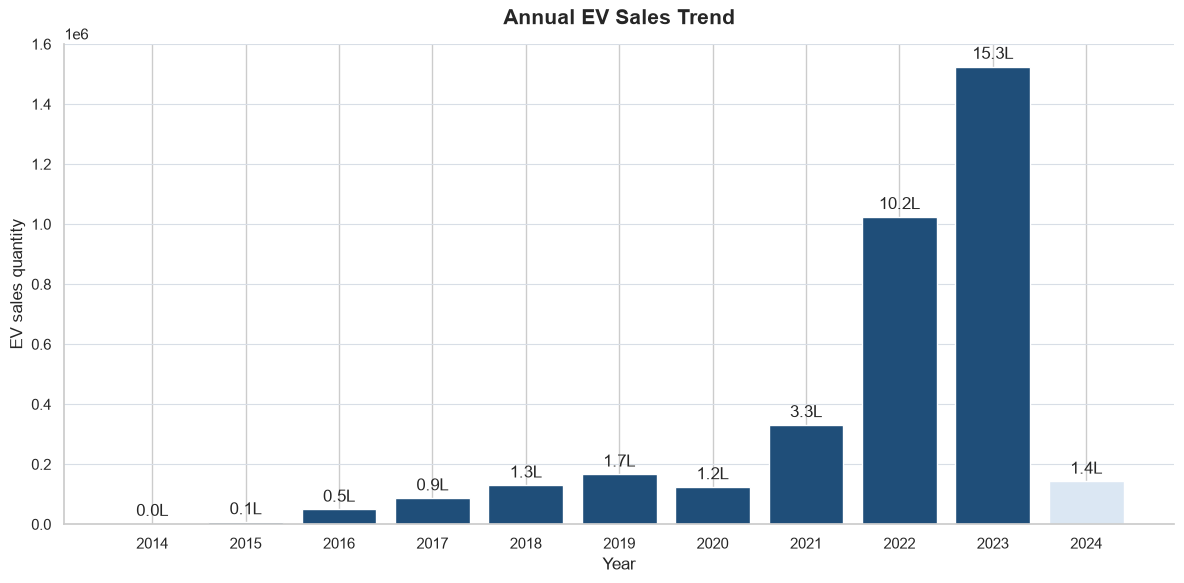

In [22]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    annual_sales["year"].astype(str),
    annual_sales["total_sales"],
    color=[base_color if status == "Complete year" else soft_color for status in annual_sales["year_status"]]
)

plt.bar_label(bars, labels=[f"{value/100000:.1f}L" for value in annual_sales["total_sales"]], padding=3)
style_plot("Annual EV Sales Trend", "Year", "EV sales quantity")
plt.show()


## Chart 2: Complete-Year Growth Rate


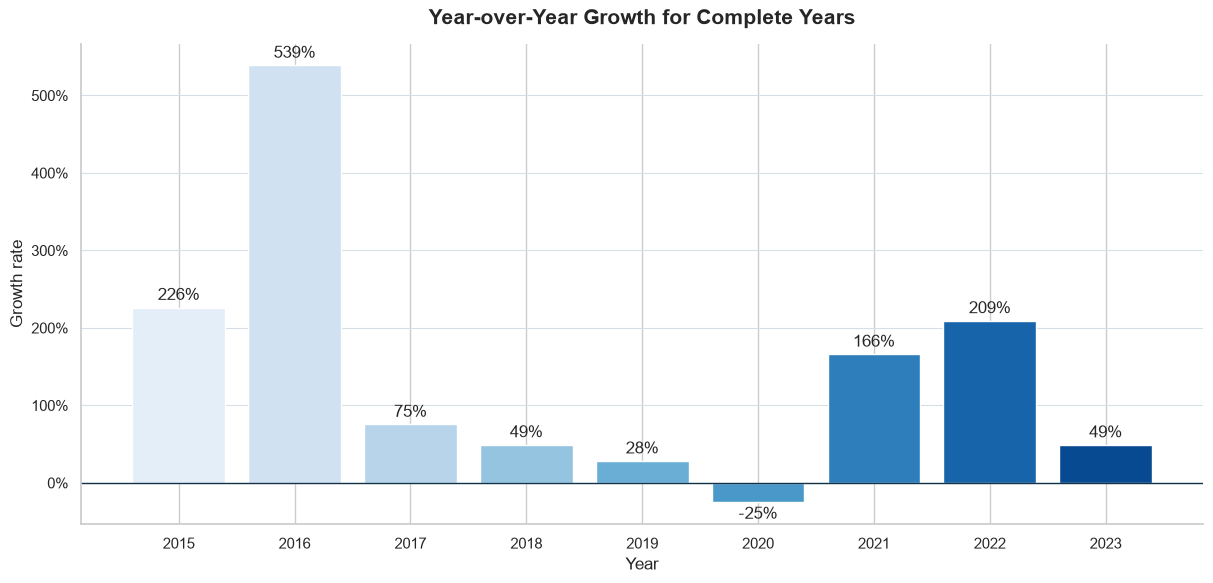

In [23]:
growth_chart = complete_annual_sales.dropna(subset=["yearly_growth"])

plt.figure(figsize=(12, 6))

bars = plt.bar(
    growth_chart["year"].astype(str),
    growth_chart["yearly_growth"],
    color=sns.color_palette("Blues", len(growth_chart))
)

plt.axhline(0, color=deep_color, linewidth=1)
plt.bar_label(bars, labels=[f"{value:.0%}" for value in growth_chart["yearly_growth"]], padding=3)
style_plot("Year-over-Year Growth for Complete Years", "Year", "Growth rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{value:.0%}"))
plt.show()


## Chart 3: Monthly EV Sales Momentum


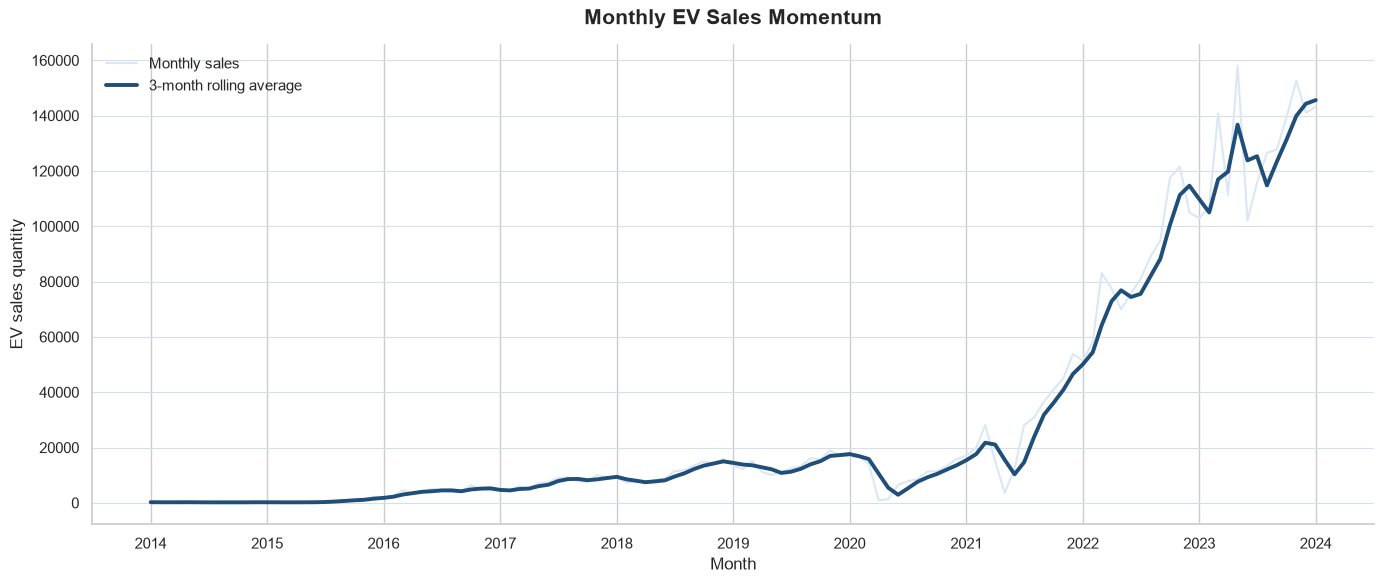

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["total_sales"],
    color=soft_color,
    linewidth=1.5,
    label="Monthly sales"
)

plt.plot(
    monthly_sales["date"],
    monthly_sales["sales_rolling_3"],
    color=base_color,
    linewidth=2.8,
    label="3-month rolling average"
)

style_plot("Monthly EV Sales Momentum", "Month", "EV sales quantity")
plt.legend(frameon=False)
plt.show()


## Chart 4: Monthly Seasonality Pattern


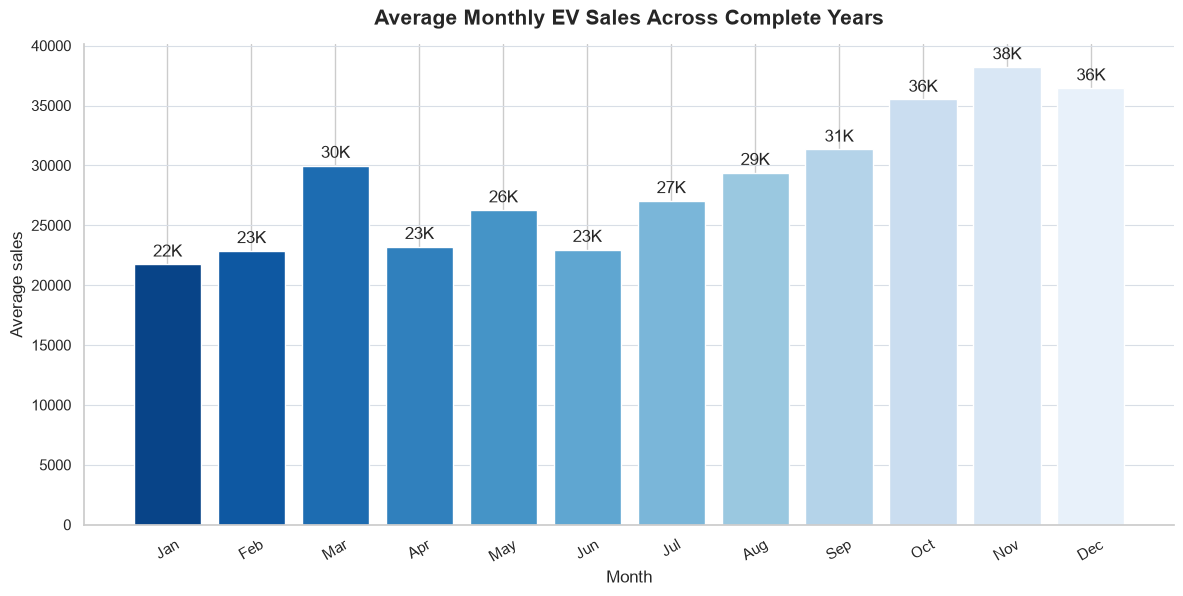

In [25]:
seasonality = (
    df[df["year_status"] == "Complete year"]
    .groupby(["month_number", "month_name"], as_index=False)
    .agg(average_sales=("ev_sales_quantity", "sum"))
)

seasonality["average_sales"] = seasonality["average_sales"] / df[df["year_status"] == "Complete year"]["year"].nunique()
seasonality = seasonality.sort_values("month_number")

plt.figure(figsize=(12, 6))

bars = plt.bar(
    seasonality["month_name"],
    seasonality["average_sales"],
    color=sns.color_palette("Blues_r", len(seasonality))
)

plt.bar_label(bars, labels=[f"{value/1000:.0f}K" for value in seasonality["average_sales"]], padding=3)
style_plot("Average Monthly EV Sales Across Complete Years", "Month", "Average sales")
plt.xticks(rotation=30)
plt.show()


## Chart 5: Top 15 States by EV Sales


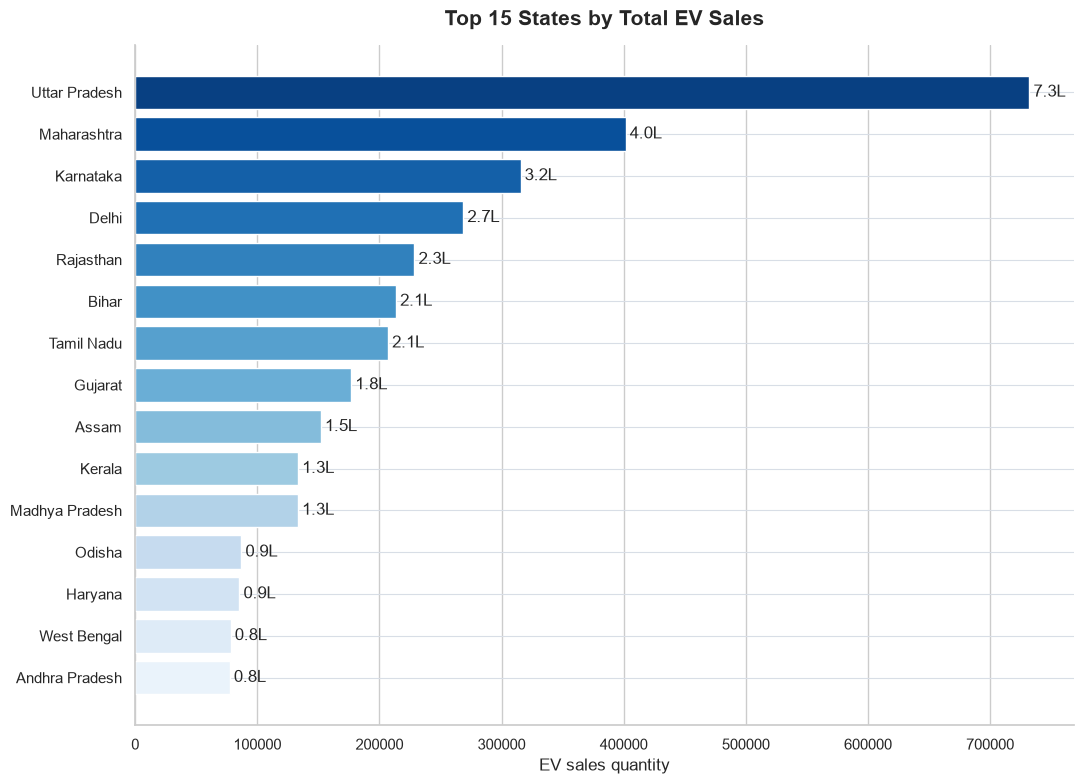

In [26]:
top_states = state_summary.head(15).sort_values("total_sales")

plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_states["state"],
    top_states["total_sales"],
    color=sns.color_palette("Blues", len(top_states))
)

plt.bar_label(bars, labels=[f"{value/100000:.1f}L" for value in top_states["total_sales"]], padding=3)
style_plot("Top 15 States by Total EV Sales", "EV sales quantity", "")
plt.show()


## Chart 6: Sales Share of Leading States


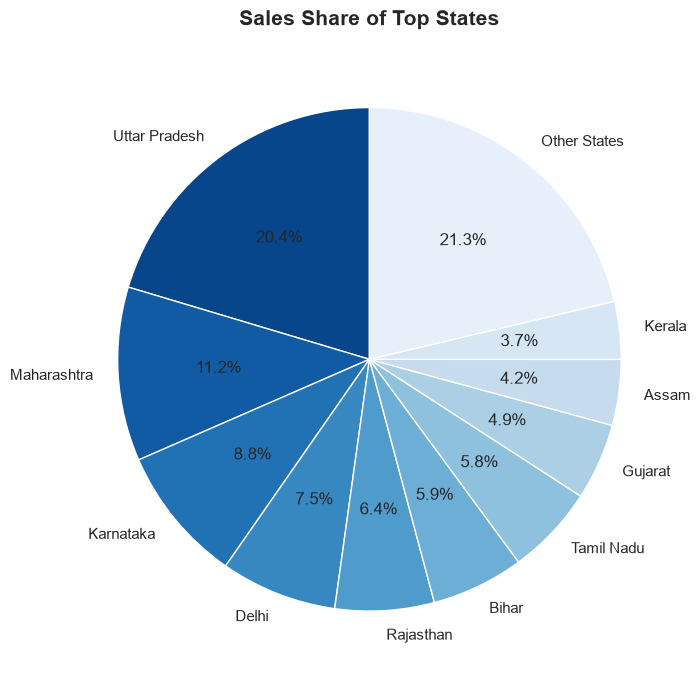

In [27]:
share_states = state_summary.head(10).copy()
other_share = 1 - share_states["sales_share"].sum()

share_plot = pd.concat([
    share_states[["state", "sales_share"]],
    pd.DataFrame({"state": ["Other States"], "sales_share": [other_share]})
])

plt.figure(figsize=(10, 7))

colors = sns.color_palette("Blues_r", len(share_plot))

plt.pie(
    share_plot["sales_share"],
    labels=share_plot["state"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

plt.title("Sales Share of Top States", fontsize=15, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()


## Chart 7: Vehicle Category Sales Mix


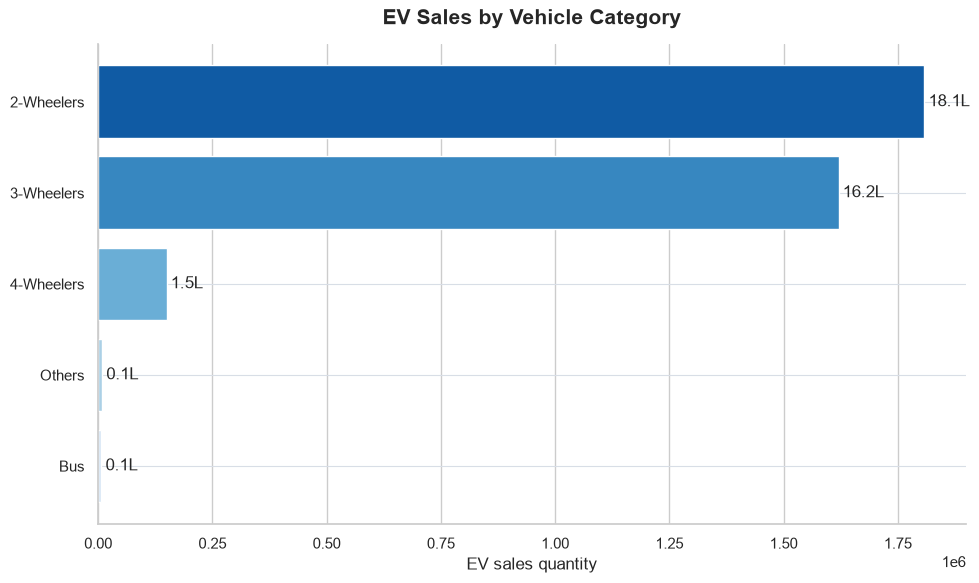

In [28]:
category_chart = category_summary.sort_values("total_sales")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    category_chart["vehicle_category"],
    category_chart["total_sales"],
    color=sns.color_palette("Blues", len(category_chart))
)

plt.bar_label(bars, labels=[f"{value/100000:.1f}L" for value in category_chart["total_sales"]], padding=3)
style_plot("EV Sales by Vehicle Category", "EV sales quantity", "")
plt.show()


## Chart 8: Top Vehicle Types by Sales


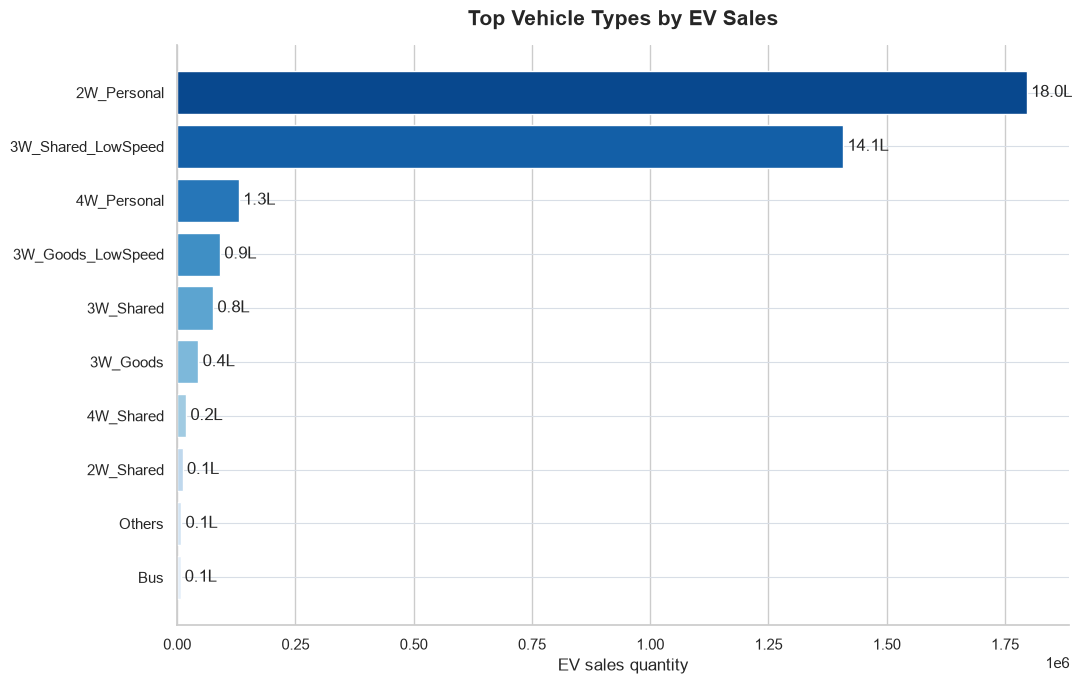

In [29]:
vehicle_type_chart = (
    df.groupby("vehicle_type", as_index=False)
    .agg(total_sales=("ev_sales_quantity", "sum"))
    .sort_values("total_sales", ascending=False)
    .head(10)
    .sort_values("total_sales")
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    vehicle_type_chart["vehicle_type"],
    vehicle_type_chart["total_sales"],
    color=sns.color_palette("Blues", len(vehicle_type_chart))
)

plt.bar_label(bars, labels=[f"{value/100000:.1f}L" for value in vehicle_type_chart["total_sales"]], padding=3)
style_plot("Top Vehicle Types by EV Sales", "EV sales quantity", "")
plt.show()


## Chart 9: Top Vehicle Classes by Sales


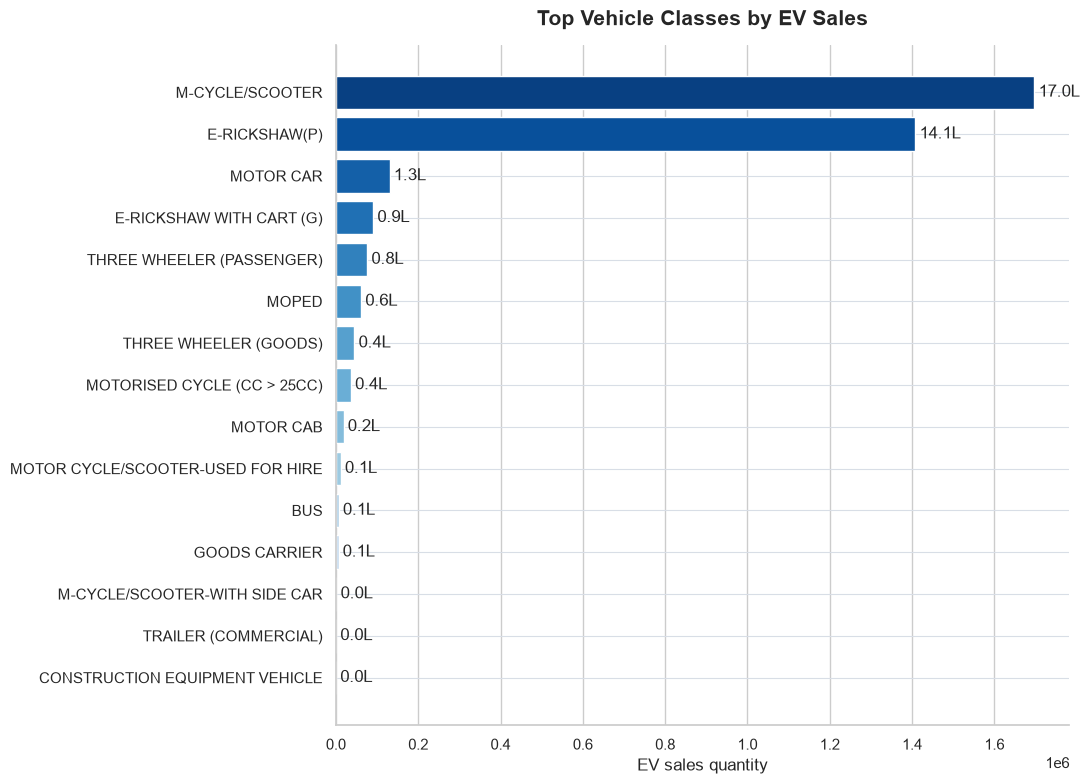

In [30]:
vehicle_class_chart = (
    df.groupby("vehicle_class", as_index=False)
    .agg(total_sales=("ev_sales_quantity", "sum"))
    .sort_values("total_sales", ascending=False)
    .head(15)
    .sort_values("total_sales")
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    vehicle_class_chart["vehicle_class"],
    vehicle_class_chart["total_sales"],
    color=sns.color_palette("Blues", len(vehicle_class_chart))
)

plt.bar_label(bars, labels=[f"{value/100000:.1f}L" for value in vehicle_class_chart["total_sales"]], padding=3)
style_plot("Top Vehicle Classes by EV Sales", "EV sales quantity", "")
plt.show()


## Chart 10: State and Vehicle Category Heatmap


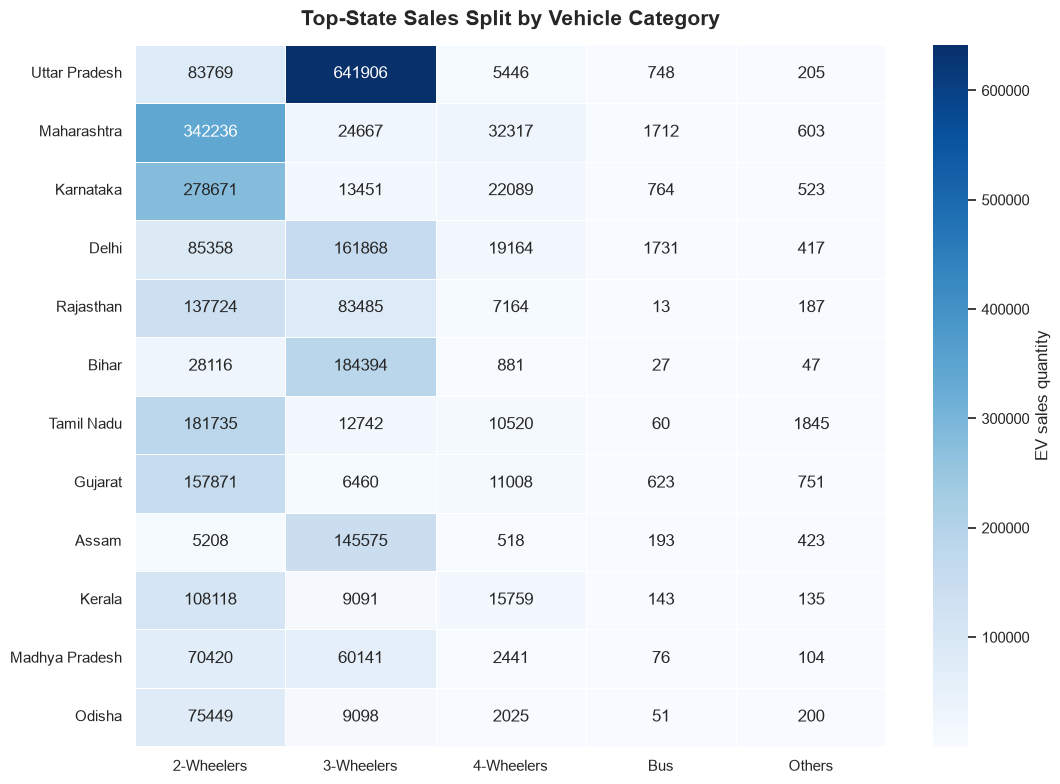

In [31]:
top_state_names = state_summary.head(12)["state"]

state_category = (
    df[df["state"].isin(top_state_names)]
    .pivot_table(
        index="state",
        columns="vehicle_category",
        values="ev_sales_quantity",
        aggfunc="sum",
        fill_value=0
    )
)

state_category = state_category.loc[top_state_names]

plt.figure(figsize=(11, 8))

sns.heatmap(
    state_category,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "EV sales quantity"}
)

plt.title("Top-State Sales Split by Vehicle Category", fontsize=15, fontweight="bold", pad=14)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Chart 11: Complete-Year Sales Trend for Top States


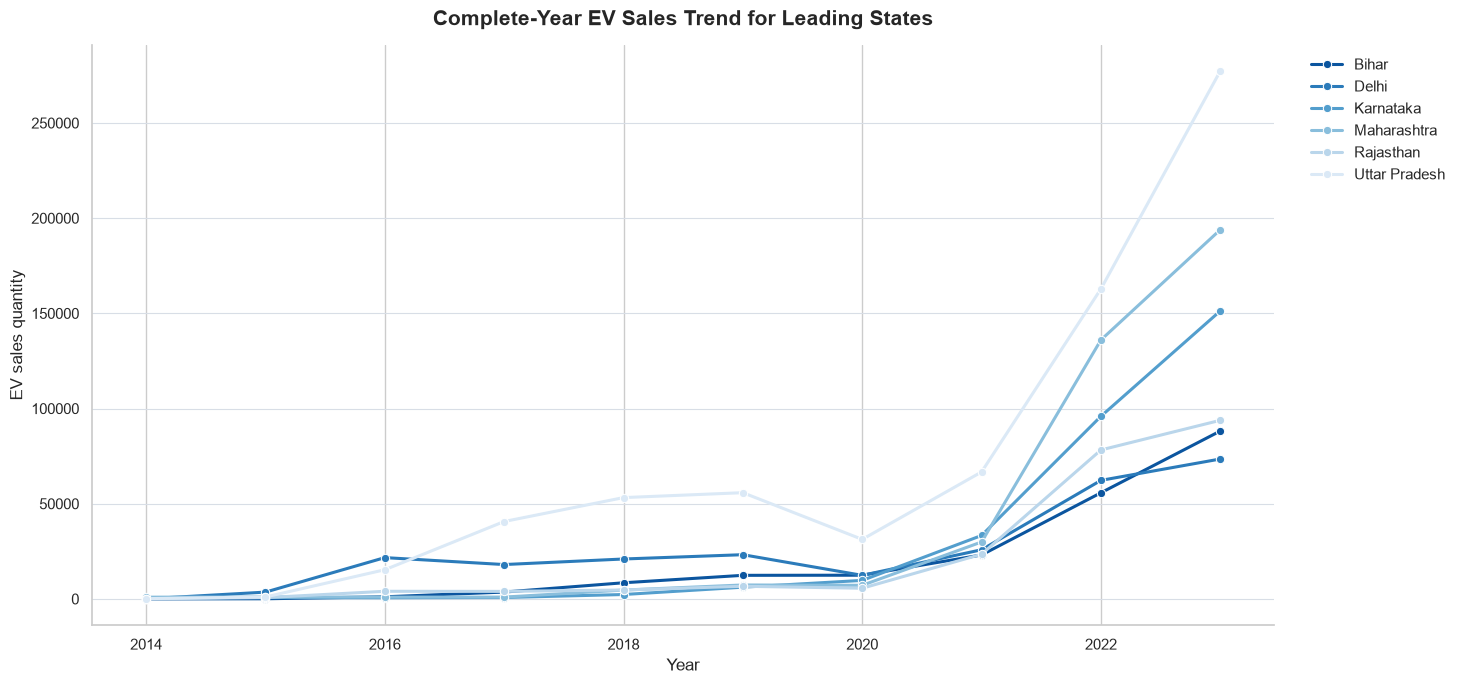

In [32]:
top_line_states = state_summary.head(6)["state"].tolist()

state_trend = (
    df[(df["state"].isin(top_line_states)) & (df["year_status"] == "Complete year")]
    .groupby(["year", "state"], as_index=False)
    .agg(total_sales=("ev_sales_quantity", "sum"))
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=state_trend,
    x="year",
    y="total_sales",
    hue="state",
    marker="o",
    linewidth=2.2,
    palette=sns.color_palette("Blues_r", len(top_line_states))
)

style_plot("Complete-Year EV Sales Trend for Leading States", "Year", "EV sales quantity")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.show()


## Chart 12: State Growth and Scale Quadrant


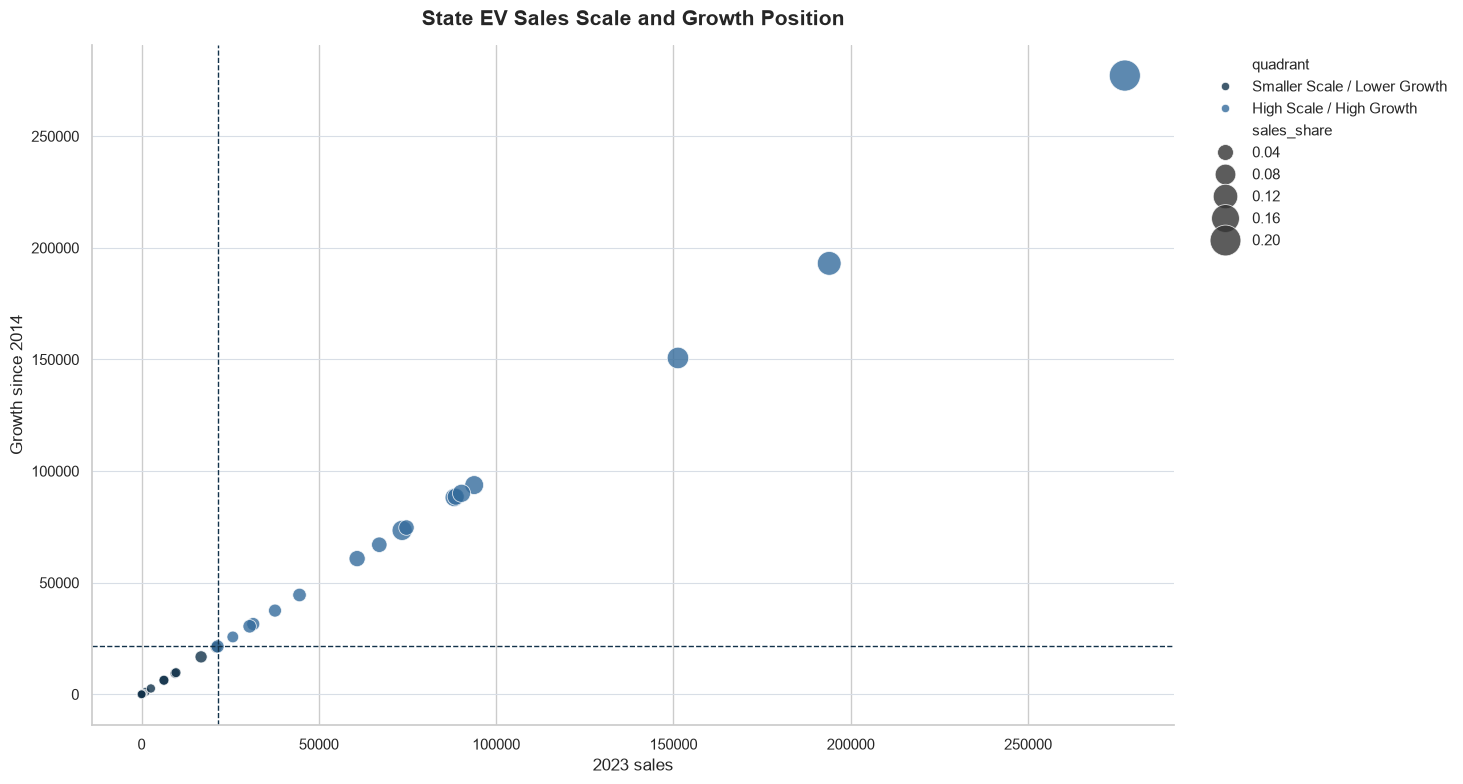

In [33]:
quadrant_data = state_growth.merge(
    state_summary[["state", "sales_share"]],
    on="state",
    how="left"
)

quadrant_data = quadrant_data[
    quadrant_data["latest_complete_year_sales"] > 0
].copy()

sales_median = quadrant_data["latest_complete_year_sales"].median()
growth_median = quadrant_data["absolute_growth"].median()

quadrant_data["quadrant"] = np.select(
    [
        (quadrant_data["latest_complete_year_sales"] >= sales_median) & (quadrant_data["absolute_growth"] >= growth_median),
        (quadrant_data["latest_complete_year_sales"] >= sales_median) & (quadrant_data["absolute_growth"] < growth_median),
        (quadrant_data["latest_complete_year_sales"] < sales_median) & (quadrant_data["absolute_growth"] >= growth_median)
    ],
    [
        "High Scale / High Growth",
        "High Scale / Lower Growth",
        "Smaller Scale / High Growth"
    ],
    default="Smaller Scale / Lower Growth"
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=quadrant_data,
    x="latest_complete_year_sales",
    y="absolute_growth",
    size="sales_share",
    sizes=(40, 500),
    hue="quadrant",
    palette=["#12324a", "#356c9c", "#6f9fc9", "#b7d0e6"],
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6
)

plt.axvline(sales_median, color=deep_color, linestyle="--", linewidth=1)
plt.axhline(growth_median, color=deep_color, linestyle="--", linewidth=1)
style_plot("State EV Sales Scale and Growth Position", f"{last_complete_year} sales", f"Growth since {first_complete_year}")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.show()


# 7. Summary Tables


### State summary


In [34]:
state_summary.head(15)


,state,total_sales,active_months,vehicle_categories,vehicle_types,sales_share,average_monthly_sales
31,Uttar Pradesh,732074,121,5,12,0.20,"6,050.20"
19,Maharashtra,401535,121,5,12,0.11,"3,318.47"
15,Karnataka,315498,121,5,12,0.09,"2,607.42"
7,Delhi,268538,121,5,11,0.07,"2,219.32"
27,Rajasthan,228573,121,5,12,0.06,"1,889.03"
4,Bihar,213465,121,5,11,0.06,"1,764.17"
29,Tamil Nadu,206902,121,5,11,0.06,"1,709.93"
10,Gujarat,176713,121,5,12,0.05,"1,460.44"
3,Assam,151917,121,5,11,0.04,"1,255.51"
16,Kerala,133246,121,5,12,0.04,"1,101.21"


### Vehicle category summary


In [35]:
category_summary


,vehicle_category,total_sales,sales_share
0,2-Wheelers,1808105,0.50
1,3-Wheelers,1620310,0.45
2,4-Wheelers,149775,0.04
4,Others,8612,0.00
3,Bus,7009,0.00


### Complete annual sales summary


In [36]:
complete_annual_sales


,year,year_status,total_sales,yearly_growth
0,2014,Complete year,2392,NaN
1,2015,Complete year,7805,2.26
2,2016,Complete year,49855,5.39
3,2017,Complete year,87420,0.75
4,2018,Complete year,130254,0.49
5,2019,Complete year,166819,0.28
6,2020,Complete year,124684,-0.25
7,2021,Complete year,331498,1.66
8,2022,Complete year,1024723,2.09
9,2023,Complete year,1525179,0.49


# 8. Saving the Pre-Processed Dataframe


In [40]:
output_file = cleaned_file.with_name("electric_vehicle_sales_processed.csv")
df.to_csv(output_file, index=False)

print("File saved successfully.")
print("Output file:", output_file)
print("Rows exported:", df.shape[0])
print("Columns exported:", df.shape[1])


File saved successfully.
Output file: C:\Users\yasha\Downloads\electric_vehicle_sales_processed.csv
Rows exported: 96845
Columns exported: 15


# 9. Key Insights


In [38]:
top_state = state_summary.iloc[0]
top_category = category_summary.iloc[0]
top_vehicle_type = (
    df.groupby("vehicle_type")["ev_sales_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

complete_year_peak = complete_annual_sales.loc[
    complete_annual_sales["total_sales"].idxmax()
]

print("KEY FINDINGS")
print("-" * 50)
print(f"Total EV sales in the dataset: {total_sales:,.0f}")
print(f"Highest complete sales year: {int(complete_year_peak['year'])} with {complete_year_peak['total_sales']:,.0f} sales")
print(f"Leading state: {top_state['state']} with {top_state['sales_share']:.1%} of sales")
print(f"Leading vehicle category: {top_category['vehicle_category']} with {top_category['sales_share']:.1%} of sales")
print(f"Leading vehicle type: {top_vehicle_type.index[0]} with {top_vehicle_type.iloc[0]:,.0f} sales")
print(f"{latest_year} is marked as partial because only {latest_year_months} month is available")


KEY FINDINGS
--------------------------------------------------
Total EV sales in the dataset: 3,593,811
Highest complete sales year: 2023 with 1,525,179 sales
Leading state: Uttar Pradesh with 20.4% of sales
Leading vehicle category: 2-Wheelers with 50.3% of sales
Leading vehicle type: 2W_Personal with 1,796,340 sales
2024 is marked as partial because only 1 month is available


## Final Observations

- EV sales accelerated strongly after 2021, with 2022 and 2023 forming the main growth period in the dataset.
- Two-wheelers and three-wheelers contribute the largest share of total EV sales.
- Uttar Pradesh, Maharashtra, Karnataka and Delhi are major EV sales contributors, but state-level growth should be compared using complete years.
- The latest year is partial, so it should not be treated as a full-year decline.
- The final dataframe is ready for dashboarding, SQL analysis or deeper forecasting work.
